In [10]:
import sympy as sp
import numpy as np
import pandas as pd

In [4]:
pip install sympy

  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
Using cached mpmath-1.3.0-py3-none-any.whl (536 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [sympy]32m1/2 [sympy]
Note: you may need to restart the kernel to use updated packages.


In [6]:
x = sp.Symbol('x')

In [11]:
f = sp.exp((x+1)**2)

In [44]:
f

exp((x + 1)**2)

In [45]:
fd = sp.diff(f)

In [46]:
fd

(2*x + 2)*exp((x + 1)**2)

In [15]:
fdd = sp.diff(fd)

In [16]:
fdd

(2*x + 2)**2*exp((x + 1)**2) + 2*exp((x + 1)**2)

In [26]:
def taylor(a):
    return sp.simplify(f.subs(x,a) + fd.subs(x,a)*(x-a) + fdd.subs(x,a)*((x-a)**2)*1/2)

In [33]:
a = [1,3,6,5]
tayl = []
for i in a:
    print(taylor(i))
    

(9*x**2 - 14*x + 6)*exp(4)
(33*x**2 - 190*x + 274)*exp(16)
(99*x**2 - 1174*x + 3481)*exp(49)
(73*x**2 - 718*x + 1766)*exp(36)


In [34]:
from scipy.stats import norm

In [35]:
def d1(T):
    return (np.log(S/K) + (r-q+sigma**2*1/2)*T)/(sigma*np.sqrt(T))

In [38]:
S = 40
K = 40
sigma = 0.3
r = 0.03
q = 0.01

In [39]:
d1(3)

np.float64(0.3752776749732568)

In [41]:
norm.cdf(d1(3))

np.float64(0.6462730161489627)

In [43]:
norm.pdf(4)

np.float64(0.00013383022576488537)

In [47]:
T = 6/12

In [4]:
import yfinance as yf

In [49]:
pip install yfinance

  Using cached yfinance-1.0-py2.py3-none-any.whl.metadata (6.0 kB)
  Using cached multitasking-0.0.12-py3-none-any.whl
  Using cached curl_cffi-0.13.0-cp39-abi3-macosx_11_0_arm64.whl.metadata (13 kB)
Using cached yfinance-1.0-py2.py3-none-any.whl (127 kB)
Using cached curl_cffi-0.13.0-cp39-abi3-macosx_11_0_arm64.whl (3.0 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [yfinance]3/7 [protobuf]
Note: you may need to restart the kernel to use updated packages.


In [5]:
apple = yf.download('AAPL' , start = '2020-01-01' , end = '2026-01-20' , auto_adjust=True)

[*********************100%***********************]  1 of 1 completed


In [6]:
apple.columns = ['Close' , 'High','Low','Open','Volume']

In [7]:
prices = apple['Close']

In [8]:
prices

Date
2020-01-02     72.468269
2020-01-03     71.763733
2020-01-06     72.335564
2020-01-07     71.995361
2020-01-08     73.153511
                 ...    
2026-01-12    260.250000
2026-01-13    261.049988
2026-01-14    259.959991
2026-01-15    258.209991
2026-01-16    255.529999
Name: Close, Length: 1519, dtype: float64

In [11]:
log_rets = np.log1p(prices.pct_change())

In [13]:
log_rets.dropna()

Date
2020-01-03   -0.009770
2020-01-06    0.007937
2020-01-07   -0.004714
2020-01-08    0.015958
2020-01-09    0.021018
                ...   
2026-01-12    0.003387
2026-01-13    0.003069
2026-01-14   -0.004184
2026-01-15   -0.006755
2026-01-16   -0.010433
Name: Close, Length: 1518, dtype: float64

In [14]:
log_rets.describe()

count    1518.000000
mean        0.000830
std         0.019937
min        -0.137708
25%        -0.008246
50%         0.001071
75%         0.011179
max         0.142618
Name: Close, dtype: float64

In [15]:
log_rets.describe()

count    1518.000000
mean        0.000830
std         0.019937
min        -0.137708
25%        -0.008246
50%         0.001071
75%         0.011179
max         0.142618
Name: Close, dtype: float64

In [17]:
std = log_rets.std() * np.sqrt(252)

In [18]:
std

np.float64(0.31648316558026635)

In [19]:
std_daily = log_rets.std()

In [20]:
std_daily

np.float64(0.019936565482472895)

In [21]:
import matplotlib.pyplot as plt

In [22]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


<Axes: >

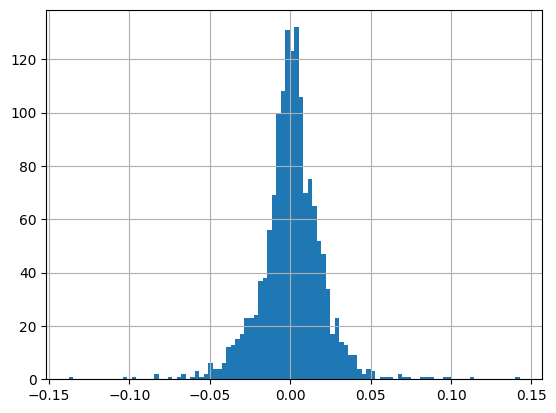

In [25]:
log_rets.hist(bins=100)

<Axes: xlabel='Date'>

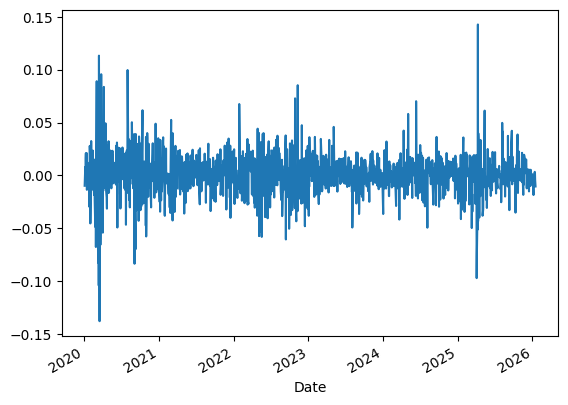

In [26]:
log_rets.plot()

<Axes: xlabel='Date'>

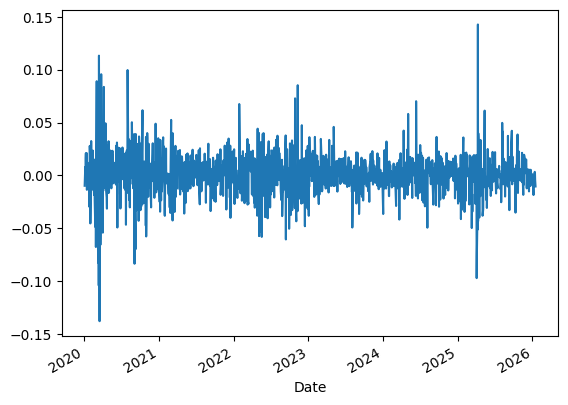

In [27]:
log_rets.plot()